In [1]:
import pandas as pd
import numpy as np
import re

In [ ]:
# -- Read in all data
matches = pd.read_csv('matches.xls', parse_dates=["event_date"]).sort_values(by="event_date")
duals = pd.read_csv('dual_meets.xls', parse_dates=["event_date"]).sort_values(by="event_date")
# -- need to correct naming conventions

# **NOTE: I MISTAKINGLY RENAMED THESE COLUMNS. team1 refers to the team that won the dual, and team2 refers to the team that lost. Ultimately nothing changes however
duals = duals.rename(columns={
    "team1_id": "home_team_id",
    "team1_rank": "home_team_rank",
    "team1_score": "home_team_score",
    "team2_id": "away_team_id",
    "team2_rank": "away_team_rank",
    "team2_score": "away_team_score"
})

wrestlers = pd.read_csv('wrestlers.xls')
teams = pd.read_csv('teams.xls')

ALL_WRESTLERS = pd.read_csv('ALL_WRESTLERS.xls')


dfs = {
    "matches": matches,
    "duals": duals,
    "wrestlers": wrestlers,
    "teams": teams,
    "ALL_WRESTLERS": ALL_WRESTLERS
}

for name, df in dfs.items():
    print(f"\n{name}")
    display(df)


matches


/tmp/ipykernel_2439/1168923380.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  matches = pd.read_csv('matches.xls', parse_dates=["event_date"]).sort_values(by="event_date")
/tmp/ipykernel_2439/1168923380.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  duals = pd.read_csv('dual_meets.xls', parse_dates=["event_date"]).sort_values(by="event_date")


,dual_id,weight_class,event_date,home_team_id,home_wrestler_id,home_name,home_rank,away_team_id,away_wrestler_id,away_name,away_rank,home_win,win_type,Result
2792,280,141,2025-11-01,24,267.0,Raymond Adams,160.0,67,825.0,John Hildebrandt,98.0,False,LDEC,LDEC 3 - 2
2828,283,197,2025-11-01,70,878.0,Kael Bennie,46.0,23,263.0,Angelo Posada,20.0,False,LDEC,LDEC 5 - 4
2829,283,285,2025-11-01,70,879.0,Jack Forbes,62.0,23,429.0,Jackson Mankowski,182.0,True,WDEC,WDEC 10 - 3
2830,284,125,2025-11-01,64,784.0,Koda Holeman,40.0,20,530.0,Jacob Macatangay,69.0,True,WMD,WMD 20 - 8
2831,284,133,2025-11-01,64,785.0,Anthony Lucio,245.0,20,226.0,Blake Boarman,57.0,False,LDEC,LDEC 8 - 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5466,547,174,2026-02-23,37,399.0,Joshua Roe,237.0,66,814.0,Beau Lewis,158.0,False,LDEC,LDEC 5 - 3
5467,547,184,2026-02-23,37,400.0,Reed Douglass,72.0,66,815.0,Andrew Barford,162.0,True,WTF,WTF5 22 - 5 6:45
5468,547,197,2026-02-23,37,911.0,Toler Hornick,207.0,66,816.0,Toby Schoffstall,74.0,False,LTF,LTF5 15 - 0 1:05
5463,547,149,2026-02-23,37,398.0,Rey Ortiz,245.0,66,811.0,Patrick Jordon,77.0,False,LFALL,LFALL 4:22



duals


,dual_id,home_team_id,home_team_rank,home_team_score,away_team_id,away_team_rank,away_team_score,event_date
279,280,24,72,19,67,76,18,2025-11-01
283,284,20,32,19,64,47,13,2025-11-01
282,283,70,36,19,23,11,12,2025-11-01
281,282,18,31,36,62,33,3,2025-11-01
280,281,27,19,20,68,21,12,2025-11-01
...,...,...,...,...,...,...,...,...
550,551,39,4,20,73,14,14,2026-02-22
549,550,52,2,32,17,5,11,2026-02-22
548,549,25,7,34,5,43,6,2026-02-22
552,553,1,25,16,18,22,15,2026-02-22


...

,wrestler_id,name
0,1,Bowen Downey
1,2,Julian Farber
2,3,Max Brady
3,4,Ethan Basile
4,5,Cael Rahnavardi
...,...,...
1507,1508,Nieko Malone
1508,1509,Max Kirby
1509,1510,Till Helms
1510,1511,Jackson Lusk



teams


,team_id,name
0,1,Northern Iowa
1,2,South Dakota State
2,3,Drexel
3,4,Northern Illinois
4,5,Central Michigan
...,...,...
73,74,Indiana
74,75,Army West Point
75,76,Wyoming
76,77,Bellarmine



ALL_WRESTLERS


,Team,Weight,Name,Class,Record
0,Air Force,125,"#28 Owens, TuckerST",SR,19 - 8
1,Air Force,125,"#157 Gonzalez, Nick",SR,0 - 1
2,Air Force,125,"#181 Tocci, Nico",JR,0 - 2
3,Air Force,125,"#212 Bohnsack, Brayden",FR,0 - 0
4,Air Force,133,"#121 Caprella, GavinST",JR,9 - 12
...,...,...,...,...,...
2640,Wyoming,197,"#3 Novak, JoeyST",JR,14 - 2
2641,Wyoming,197,"#88 Henry, GunnerRS",FR,6 - 3
2642,Wyoming,285,"#11 Carroll, ChristianST",SO,16 - 4
2643,Wyoming,285,"#182 McBride, Winston",SO,1 - 0


# The purpose of this notebook is to merge and clean the data, and create some df's to visualize in tableau

## TABLEAU VISUALZATION CREATION: First lets save some general info on win types

In [3]:
# -- Win Counts(WITH WEIGHT FILTER)
matches_weight_copy = matches.copy()
matches_weight_copy['win_type'] = matches_weight_copy['win_type'].str[1:] 
matches_weight_copy = matches_weight_copy.groupby(["weight_class", 'win_type'],as_index=False).size()
matches_weight_copy['Division'] = matches_weight_copy['weight_class']
matches_weight_copy = matches_weight_copy[['win_type', 'size', 'Division']]

mathces_wins_all = matches.win_type.str[1:].value_counts().to_frame("size").reset_index()
mathces_wins_all["Division"] = "All"

match_win_type_counts = pd.concat([mathces_wins_all, matches_weight_copy])
match_win_type_counts = match_win_type_counts.rename(columns={'size':'count'})

#match_win_type_counts.to_csv('win_types.csv', index=False)

match_win_type_counts

,win_type,count,Division
0,DEC,2621,All
1,MD,1121,All
2,TF,955,All
3,FALL,592,All
4,SV,280,All
...,...,...,...
81,INJ,5,285
82,MD,87,285
83,SV,32,285
84,TB,1,285


## TABLEAU VISUALIZATION CREATION: POINT DIFFERENCE

In [4]:
# Make a copy of the dataframe
matches_with_scores = matches.copy()

# Define win types that have associated scores
score_win_types = ['SV', 'DEC', 'TB', 'MD', 'TF']

# Function to extract scores from result
def extract_scores(row):
    win_type = row['win_type']
    result = row['Result']
    home_win = row['home_win']
    
    # Check if this win type has scores
    has_scores = any(score_type in win_type for score_type in score_win_types)
    
    if not has_scores:
        return pd.Series([None, None, None])
    
    try:
        # Split the result and extract numbers
        parts = result.split()
        scores = [int(x) for x in parts if x.isdigit()]
        
        if len(scores) >= 2:
            score1, score2 = scores[0], scores[1]
            
            # Assign home and away scores based on who won
            if home_win:  # Home won
                home_score = score1
                away_score = score2
            else:  # Away won
                home_score = score2
                away_score = score1
            
            # Calculate absolute point difference
            abs_diff = abs(score1 - score2)
            
            return pd.Series([home_score, away_score, abs_diff])
    except:
        pass
    
    return pd.Series([None, None, None])

# Apply the function to create new columns
matches_with_scores[['home_score', 'away_score', 'abs_diff']] = matches_with_scores.apply(extract_scores, axis=1)

# Also create a total_points column
matches_with_scores['total_points'] = matches_with_scores.apply(
    lambda row: row['home_score'] + row['away_score'] 
    if pd.notna(row['home_score']) and pd.notna(row['away_score']) 
    else None, 
    axis=1
)

# Create a scoreline column (winner score - loser score)
def create_scoreline(row):
    if pd.notna(row['home_score']) and pd.notna(row['away_score']):
        if row['home_score'] >= row['away_score']:
            return f"{int(row['home_score'])}-{int(row['away_score'])}"
        else:
            return f"{int(row['away_score'])}-{int(row['home_score'])}"
    return None

matches_with_scores['scoreline'] = matches_with_scores.apply(create_scoreline, axis=1)

In [5]:
# -- Only save subset
matches_with_scores_copy = matches_with_scores[["weight_class", "home_name", "away_name", "home_score", "away_score", "total_points"]].dropna()
#matches_with_scores_copy.to_csv('match_score_stats.csv', index=False)
matches_with_scores_copy

,weight_class,home_name,away_name,home_score,away_score,total_points
2792,141,Raymond Adams,John Hildebrandt,2.0,3.0,5.0
2828,197,Kael Bennie,Angelo Posada,4.0,5.0,9.0
2829,285,Jack Forbes,Jackson Mankowski,10.0,3.0,13.0
2830,125,Koda Holeman,Jacob Macatangay,20.0,8.0,28.0
2831,133,Anthony Lucio,Blake Boarman,2.0,8.0,10.0
...,...,...,...,...,...,...
5464,157,Phil Cuttino,Raymond Cmil,4.0,7.0,11.0
5466,174,Joshua Roe,Beau Lewis,3.0,5.0,8.0
5467,184,Reed Douglass,Andrew Barford,22.0,5.0,27.0
5468,197,Toler Hornick,Toby Schoffstall,0.0,15.0,15.0


In [6]:
# -- Also save point differentials
scorline = matches_with_scores['scoreline'].dropna().value_counts().nlargest(10).to_frame('Count').reset_index()
scorline.to_csv('scorlines.csv')
scorline

,scoreline,Count
0,4-1,316
1,4-2,225
2,19-4,136
3,5-1,125
4,2-1,111
5,5-2,109
6,7-3,97
7,2-0,95
8,8-2,90
9,11-2,83


## TABLEAU VIS: Now, we will look at team records

In [7]:
# 1. Team Dual Records
def create_team_records(duals):
    # Calculate wins and losses for each team
    team_records = []
    
    # Get all unique team IDs from both home and away
    all_teams = pd.concat([duals['home_team_id'], duals['away_team_id']]).unique()
    
    for team_id in all_teams:
        # Home games
        home_games = duals[duals['home_team_id'] == team_id]
        home_wins = len(home_games[home_games['home_team_score'] > home_games['away_team_score']])
        home_losses = len(home_games[home_games['home_team_score'] < home_games['away_team_score']])
        
        # Away games
        away_games = duals[duals['away_team_id'] == team_id]
        away_wins = len(away_games[away_games['away_team_score'] > away_games['home_team_score']])
        away_losses = len(away_games[away_games['away_team_score'] < away_games['home_team_score']])
        
        total_wins = home_wins + away_wins
        total_losses = home_losses + away_losses
        total_duals = total_wins + total_losses
        
        if total_duals > 0:
            win_pct = total_wins / total_duals
            team_records.append({
                'team_id': team_id,
                'wins': total_wins,
                'losses': total_losses,
                'total_duals': total_duals,
                'win_percentage': round(win_pct, 3),
                'home_wins': home_wins,
                'away_wins': away_wins
            })
    
    team_records_df = pd.DataFrame(team_records)
    
    # Merge with team names
    team_records_df = team_records_df.merge(teams, left_on='team_id', right_on='team_id', how='left')
    
    return team_records_df.sort_values('win_percentage', ascending=False)

team_records = create_team_records(duals)
#print("Team Records (Top 10):")
display(team_records[['name', 'wins', 'losses', 'win_percentage', 'home_wins', 'away_wins']].head(10))
#print("\n" + "="*80 + "\n")

# Keep only what we need
record_df = team_records[['name','wins','losses']].copy()
record_df.rename(columns={'name':'team'}, inplace=True)

# Convert to long format
record_long = record_df.melt(
    id_vars='team',
    value_vars=['wins','losses'],
    var_name='result',
    value_name='count'
)

# Clean labels
record_long['result'] = record_long['result'].str.capitalize()

record_long.to_csv('team_dual_records.csv')
team_records[["name", "win_percentage"]].to_csv('team_dual_rate.csv', index=False)

record_long

,name,wins,losses,win_percentage,home_wins,away_wins
28,Penn State,15,0,1.000,15,0
24,Ohio State,18,1,0.947,18,0
9,Oklahoma State,15,1,0.938,15,0
57,Iowa State,11,2,0.846,11,0
31,SIU Edwardsville,8,2,0.800,8,0
15,NC State,15,4,0.789,15,0
49,Columbia,11,3,0.786,11,0
8,Virginia Tech,11,3,0.786,11,0
45,Oregon State,7,2,0.778,7,0
4,Pittsburgh,11,4,0.733,11,0


,team,result,count
0,Penn State,Wins,15
1,Ohio State,Wins,18
2,Oklahoma State,Wins,15
3,Iowa State,Wins,11
4,SIU Edwardsville,Wins,8
...,...,...,...
151,CSU Bakersfield,Losses,12
152,Morgan State,Losses,16
153,Campbell,Losses,19
154,LIU,Losses,16


In [8]:
# Merge team names
duals_named = duals.merge(
    teams.rename(columns={'team_id':'home_team_id','name':'home_team'}),
    on='home_team_id'
).merge(
    teams.rename(columns={'team_id':'away_team_id','name':'away_team'}),
    on='away_team_id'
)

# Determine winner / loser + margin
duals_named['margin'] = abs(duals_named['home_team_score'] - duals_named['away_team_score'])

duals_named['winning_team'] = np.where(
    duals_named['home_team_score'] > duals_named['away_team_score'],
    duals_named['home_team'],
    duals_named['away_team']
)

duals_named['losing_team'] = np.where(
    duals_named['home_team_score'] > duals_named['away_team_score'],
    duals_named['away_team'],
    duals_named['home_team']
)

duals_named['winning_score'] = np.where(
    duals_named['home_team_score'] > duals_named['away_team_score'],
    duals_named['home_team_score'],
    duals_named['away_team_score']
)

duals_named['losing_score'] = np.where(
    duals_named['home_team_score'] > duals_named['away_team_score'],
    duals_named['away_team_score'],
    duals_named['home_team_score']
)

# Final clean dataset for Tableau
dual_margin = duals_named[[
    'dual_id',
    'event_date',
    'home_team',
    'away_team',
    'winning_team',
    'losing_team',
    'winning_score',
    'losing_score',
    'margin'
]]

dual_margin.head()

,dual_id,event_date,home_team,away_team,winning_team,losing_team,winning_score,losing_score,margin
0,280,2025-11-01,Duke,Sacred Heart,Duke,Sacred Heart,19,18,1
1,284,2025-11-01,Purdue,Cal Poly,Purdue,Cal Poly,19,13,6
2,283,2025-11-01,Utah Valley,Stanford,Utah Valley,Stanford,19,12,7
3,282,2025-11-01,Wisconsin,North Dakota State,Wisconsin,North Dakota State,36,3,33
4,281,2025-11-01,Pittsburgh,Navy,Pittsburgh,Navy,20,12,8


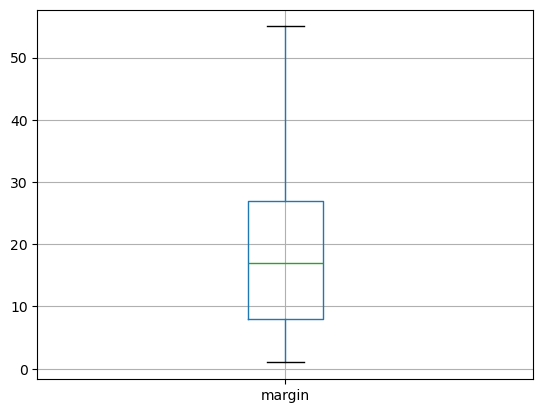

In [9]:
import matplotlib.pyplot as plt

dual_margin.boxplot(column='margin')
plt.show()

In [10]:
duals_named

,dual_id,home_team_id,home_team_rank,home_team_score,away_team_id,away_team_rank,away_team_score,event_date,home_team,away_team,margin,winning_team,losing_team,winning_score,losing_score
0,280,24,72,19,67,76,18,2025-11-01,Duke,Sacred Heart,1,Duke,Sacred Heart,19,18
1,284,20,32,19,64,47,13,2025-11-01,Purdue,Cal Poly,6,Purdue,Cal Poly,19,13
2,283,70,36,19,23,11,12,2025-11-01,Utah Valley,Stanford,7,Utah Valley,Stanford,19,12
3,282,18,31,36,62,33,3,2025-11-01,Wisconsin,North Dakota State,33,Wisconsin,North Dakota State,36,3
4,281,27,19,20,68,21,12,2025-11-01,Pittsburgh,Navy,8,Pittsburgh,Navy,20,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,551,39,4,20,73,14,14,2026-02-22,Iowa State,Missouri,6,Iowa State,Missouri,20,14
580,550,52,2,32,17,5,11,2026-02-22,Oklahoma State,Iowa,21,Oklahoma State,Iowa,32,11
581,549,25,7,34,5,43,6,2026-02-22,Michigan,Central Michigan,28,Michigan,Central Michigan,34,6
582,553,1,25,16,18,22,15,2026-02-22,Northern Iowa,Wisconsin,1,Northern Iowa,Wisconsin,16,15


## MAJOR ERROR 1: NICKNAMES
### We will soon start meging dataframes, and we need data to be as consistent as possible. In previous notebooks we found this to be problematic so we will fix it

In [11]:
# Josh Lange&Joshua Lange; Carter&Douglas Shiper; JD and Jesse Perez
anomolies = ["Josh Lange", "Joshua Lange", "Carter Shipers", "Douglas Shipers", "Jesse Perez", "JD Perez"]

In [12]:
# -- Clean ALL_WRESTLERS(Contains wrestler class)
STATUS_CODES = ["ST", "RS", "RSFR", "RSSO", "RSJR"]

def clean_name(name_str):
    # Extract rank
    rank_match = re.search(r"#(\d+)", name_str)
    rank = int(rank_match.group(1)) if rank_match else None

    # Remove rank
    name_only = re.sub(r"#\d+\s*", "", name_str)

    # Remove trailing known status ONLY if attached
    for status in STATUS_CODES:
        if name_only.endswith(status):
            name_only = name_only[:-len(status)]
            break

    name_only = name_only.strip()

    # Split last and first
    if "," in name_only:
        last, first = name_only.split(",", 1)
        return rank, last.strip(), first.strip()

    return rank, None, None
    
#🚀 Apply It To Your DataFrame
all_wrestler_info = ALL_WRESTLERS.copy()
all_wrestler_info[["Rank", "Last", "First"]] = all_wrestler_info["Name"].apply(
    lambda x: pd.Series(clean_name(x))
)

all_wrestler_info['name'] = all_wrestler_info['First'] + " " + all_wrestler_info['Last']

all_wrestler_info

,Team,Weight,Name,Class,Record,Rank,Last,First,name
0,Air Force,125,"#28 Owens, TuckerST",SR,19 - 8,28,Owens,Tucker,Tucker Owens
1,Air Force,125,"#157 Gonzalez, Nick",SR,0 - 1,157,Gonzalez,Nick,Nick Gonzalez
2,Air Force,125,"#181 Tocci, Nico",JR,0 - 2,181,Tocci,Nico,Nico Tocci
3,Air Force,125,"#212 Bohnsack, Brayden",FR,0 - 0,212,Bohnsack,Brayden,Brayden Bohnsack
4,Air Force,133,"#121 Caprella, GavinST",JR,9 - 12,121,Caprella,Gavin,Gavin Caprella
...,...,...,...,...,...,...,...,...,...
2640,Wyoming,197,"#3 Novak, JoeyST",JR,14 - 2,3,Novak,Joey,Joey Novak
2641,Wyoming,197,"#88 Henry, GunnerRS",FR,6 - 3,88,Henry,Gunner,Gunner Henry
2642,Wyoming,285,"#11 Carroll, ChristianST",SO,16 - 4,11,Carroll,Christian,Christian Carroll
2643,Wyoming,285,"#182 McBride, Winston",SO,1 - 0,182,McBride,Winston,Winston McBride


In [13]:
# JD/Jesse Perez case is rather simple as we just need to switch it in the all wrestler info df
all_wrestler_info.loc[
    all_wrestler_info["name"] == "JD Perez",
    "name"
] = "Jesse Perez"

display(all_wrestler_info.query('name in @anomolies'))

#-- We will join using 'name' col

,Team,Weight,Name,Class,Record,Rank,Last,First,name
318,Brown,133,"#254 Shipers, DouglasST",FR,0 - 14,254,Shipers,Douglas,Douglas Shipers
713,Davidson,174,"#238 Lange, Joshua",SO,2 - 14,238,Lange,Joshua,Joshua Lange
1780,Northwestern,184,"#60 Perez, JDST",SR,9 - 13,60,Perez,JD,Jesse Perez


In [14]:
# -- lets now look at more complex cases. Shipers and Lange
display(matches.query('home_name == "Joshua Lange" or away_name == "Joshua Lange" or home_name == "Josh Lange" or away_name == "Josh Lange"'))
print(); print()
matches.query('home_name == "Douglas Shipers" or away_name == "Douglas Shipers" or home_name == "Carter Shipers" or away_name == "Carter Shipers"')

,dual_id,weight_class,event_date,home_team_id,home_wrestler_id,home_name,home_rank,away_team_id,away_wrestler_id,away_name,away_rank,home_win,win_type,Result
1737,174,184,2025-11-23,65,906.0,Josh Lange,240.0,20,232.0,James Rowley,28.0,False,LDEC,LDEC 6 - 1
1397,140,184,2025-12-07,12,136.0,Shane Cartagena-Walsh,13.0,65,906.0,Josh Lange,240.0,True,WFALL,WFALL 5:25
1087,109,184,2025-12-18,65,906.0,Josh Lange,240.0,72,897.0,James Conway,7.0,False,LTF,LTF5 17 - 1 5:59
5088,509,197,2026-02-07,66,815.0,Andrew Barford,159.0,65,1428.0,Joshua Lange,241.0,True,WMD,WMD 19 - 6
4796,480,174,2026-02-13,65,1428.0,Joshua Lange,241.0,38,410.0,Joe Zovistoski,121.0,False,LDEC,LDEC 9 - 4
4528,453,197,2026-02-15,61,741.0,Adam Ortega,96.0,65,1428.0,Joshua Lange,241.0,True,WDEC,WDEC 10 - 5


,dual_id,weight_class,event_date,home_team_id,home_wrestler_id,home_name,home_rank,away_team_id,away_wrestler_id,away_name,away_rank,home_win,win_type,Result
2361,237,133,2025-11-15,78,1055.0,Douglas Shipers,242.0,65,799.0,Luke Passarelli,196.0,False,LFALL,LFALL 3:42
1471,148,133,2025-12-05,19,216.0,Jacob Van Dee,8.0,78,1055.0,Douglas Shipers,242.0,True,WFALL,WFALL 1:14
1571,158,133,2025-12-05,45,510.0,Branden Rozanski,187.0,78,1055.0,Douglas Shipers,242.0,True,WTF,WTF5 16 - 0 6:05
3201,321,133,2026-01-16,78,1055.0,Douglas Shipers,252.0,44,473.0,Gable Strickland,58.0,False,LFALL,LFALL 2:20
3191,320,133,2026-01-16,78,1055.0,Douglas Shipers,252.0,46,498.0,Bryce Manera,94.0,False,LFALL,LFALL 1:20
3221,323,133,2026-01-16,37,395.0,Fernando Dominguez,215.0,78,1055.0,Douglas Shipers,252.0,True,WDEC,WDEC 10 - 3
3591,360,133,2026-01-24,16,570.0,Brett Ungar,35.0,78,1055.0,Douglas Shipers,252.0,True,WFALL,WFALL 3:39
3691,370,133,2026-01-24,35,375.0,Dillon Arrick,144.0,78,1055.0,Douglas Shipers,252.0,True,WFALL,WFALL 3:38
4061,407,133,2026-01-31,78,1055.0,Douglas Shipers,252.0,50,556.0,Evan Mougalian,10.0,False,LFALL,LFALL 2:38
5441,545,133,2026-02-01,78,1408.0,Carter Shipers,258.0,42,1093.0,Ethan Rivera,48.0,False,LFALL,LFALL 0:41


In [15]:
# -- We see that even though these are the same wrestler, they are treated differently
def reconcile_wrestlers(df):
    """
    Standardizes duplicate wrestler identities across home and away columns.
    """

    # Mapping dictionary
    replacements = {
        1408.0: {"new_id": 1055.0, "new_name": "Douglas Shipers"},
        906.0:  {"new_id": 1428.0, "new_name": "Joshua Lange"},
    }

    df = df.copy()

    # Update home side
    for old_id, new_info in replacements.items():
        mask = df["home_wrestler_id"] == old_id
        df.loc[mask, "home_wrestler_id"] = new_info["new_id"]
        df.loc[mask, "home_name"] = new_info["new_name"]

    # Update away side
    for old_id, new_info in replacements.items():
        mask = df["away_wrestler_id"] == old_id
        df.loc[mask, "away_wrestler_id"] = new_info["new_id"]
        df.loc[mask, "away_name"] = new_info["new_name"]

    return df

In [16]:
# -- Update matches
matches_updated1 = reconcile_wrestlers(matches)

# -- Verify
display(matches_updated1.query(
    'home_name.str.contains("Shipers") or away_name.str.contains("Shipers")',
    engine="python"
))

print()

matches_updated1.query(
    'home_name.str.contains("Lange") or away_name.str.contains("Lange")',
    engine="python"
)

,dual_id,weight_class,event_date,home_team_id,home_wrestler_id,home_name,home_rank,away_team_id,away_wrestler_id,away_name,away_rank,home_win,win_type,Result
2361,237,133,2025-11-15,78,1055.0,Douglas Shipers,242.0,65,799.0,Luke Passarelli,196.0,False,LFALL,LFALL 3:42
1471,148,133,2025-12-05,19,216.0,Jacob Van Dee,8.0,78,1055.0,Douglas Shipers,242.0,True,WFALL,WFALL 1:14
1571,158,133,2025-12-05,45,510.0,Branden Rozanski,187.0,78,1055.0,Douglas Shipers,242.0,True,WTF,WTF5 16 - 0 6:05
3201,321,133,2026-01-16,78,1055.0,Douglas Shipers,252.0,44,473.0,Gable Strickland,58.0,False,LFALL,LFALL 2:20
3191,320,133,2026-01-16,78,1055.0,Douglas Shipers,252.0,46,498.0,Bryce Manera,94.0,False,LFALL,LFALL 1:20
3221,323,133,2026-01-16,37,395.0,Fernando Dominguez,215.0,78,1055.0,Douglas Shipers,252.0,True,WDEC,WDEC 10 - 3
3591,360,133,2026-01-24,16,570.0,Brett Ungar,35.0,78,1055.0,Douglas Shipers,252.0,True,WFALL,WFALL 3:39
3691,370,133,2026-01-24,35,375.0,Dillon Arrick,144.0,78,1055.0,Douglas Shipers,252.0,True,WFALL,WFALL 3:38
4061,407,133,2026-01-31,78,1055.0,Douglas Shipers,252.0,50,556.0,Evan Mougalian,10.0,False,LFALL,LFALL 2:38
5441,545,133,2026-02-01,78,1055.0,Douglas Shipers,258.0,42,1093.0,Ethan Rivera,48.0,False,LFALL,LFALL 0:41


,dual_id,weight_class,event_date,home_team_id,home_wrestler_id,home_name,home_rank,away_team_id,away_wrestler_id,away_name,away_rank,home_win,win_type,Result
2579,258,285,2025-11-08,13,575.0,Luke Luffman,11.0,33,1099.0,Steyn De Lange,86.0,True,WDEC,WDEC 4 - 0
1989,199,285,2025-11-16,33,1099.0,Steyn De Lange,86.0,26,902.0,Max Vanadia,32.0,False,LDEC,LDEC 6 - 4
1737,174,184,2025-11-23,65,1428.0,Joshua Lange,240.0,20,232.0,James Rowley,28.0,False,LDEC,LDEC 6 - 1
1709,171,285,2025-11-23,30,333.0,Brock Kehler,82.0,33,1099.0,Steyn De Lange,86.0,True,WDEC,WDEC 4 - 2
1397,140,184,2025-12-07,12,136.0,Shane Cartagena-Walsh,13.0,65,1428.0,Joshua Lange,240.0,True,WFALL,WFALL 5:25
1087,109,184,2025-12-18,65,1428.0,Joshua Lange,240.0,72,897.0,James Conway,7.0,False,LTF,LTF5 17 - 1 5:59
5088,509,197,2026-02-07,66,815.0,Andrew Barford,159.0,65,1428.0,Joshua Lange,241.0,True,WMD,WMD 19 - 6
4796,480,174,2026-02-13,65,1428.0,Joshua Lange,241.0,38,410.0,Joe Zovistoski,121.0,False,LDEC,LDEC 9 - 4
4528,453,197,2026-02-15,61,741.0,Adam Ortega,96.0,65,1428.0,Joshua Lange,241.0,True,WDEC,WDEC 10 - 5


In [17]:
# -- Get rid of redundant info from wrestlers
display(wrestlers.query('name == "Carter Shipers" or name == "Josh Lange"'))

wrestlers_updated1 = wrestlers.drop([905,1407])

wrestlers_updated1[wrestlers_updated1.isna().any(axis=1)]


,wrestler_id,name
905,906,Josh Lange
1407,1408,Carter Shipers


,wrestler_id,name


## -- MAJOR ISSUE. DUPLICATION of NAMES
### From other notebook, we saw there were some duplicate wrestlers(wrestlers with the exact same name)
### James Conway, Landen Johnson, Nathan Taylor are the culprits

In [18]:
all_wrestler_info.name.value_counts().head()

name
James Conway      2
Nathan Taylor     2
Landen Johnson    2
Carson Babcock    1
Drew Fox          1
Name: count, dtype: int64

In [19]:
# -- SAVE TOTAL NUM OF WRESTLERS
TOTAL_WRESTLERS = all_wrestler_info.name.value_counts().sum()
TOTAL_WRESTLERS

2645

In [20]:
culprits = ['James Conway', 'Landen Johnson', 'Nathan Taylor']

In [21]:
# -- Look for name and team_id pair(if they differ, they are two different wrestlers)
for c in culprits:
    print(c)
    display(matches.query('home_name == @c or away_name == @c'))
    print(); print()

James Conway


,dual_id,weight_class,event_date,home_team_id,home_wrestler_id,home_name,home_rank,away_team_id,away_wrestler_id,away_name,away_rank,home_win,win_type,Result
2007,201,184,2025-11-16,72,897.0,James Conway,7.0,45,494.0,Anthony D'Alesio,98.0,True,WTF,WTF5 19 - 3 6:38
1664,167,157,2025-11-24,73,897.0,James Conway,19.0,13,143.0,Kannon Webster,8.0,False,LDEC,LDEC 4 - 1
1484,149,157,2025-12-05,73,897.0,James Conway,19.0,19,219.0,Antrell Taylor,5.0,False,LDEC,LDEC 4 - 2
1494,150,157,2025-12-05,73,897.0,James Conway,19.0,45,491.0,Brayden Roberts,55.0,True,WSV,WSV-1 4 - 1
1144,115,157,2025-12-14,1,508.0,Robert Weston,58.0,73,897.0,James Conway,19.0,False,LDEC,LDEC 6 - 3
1067,107,184,2025-12-18,71,887.0,Brian Burburjia,53.0,72,897.0,James Conway,7.0,False,LMD,LMD 14 - 2
1117,112,184,2025-12-18,37,401.0,Josh Henderson,248.0,72,897.0,James Conway,7.0,False,LTF,LTF5 19 - 4 4:52
1087,109,184,2025-12-18,65,906.0,Josh Lange,240.0,72,897.0,James Conway,7.0,False,LTF,LTF5 17 - 1 5:59
3495,350,165,2026-01-15,29,319.0,Nicco Ruiz,15.0,73,897.0,James Conway,24.0,True,WDEC,WDEC 8 - 1
3155,316,165,2026-01-17,70,875.0,Zyon Trujillo,87.0,73,897.0,James Conway,24.0,False,LFALL,LFALL 1 - 0




Landen Johnson


,dual_id,weight_class,event_date,home_team_id,home_wrestler_id,home_name,home_rank,away_team_id,away_wrestler_id,away_name,away_rank,home_win,win_type,Result
1004,101,157,2025-12-19,4,38.0,Landen Johnson,45.0,40,437.0,Christopher Hamblin,30.0,False,LDEC,LDEC 5 - 2
214,22,157,2026-01-09,7,72.0,Jimmy Harrington,27.0,4,38.0,Landen Johnson,45.0,True,WDEC,WDEC 3 - 2
174,18,157,2026-01-09,4,38.0,Landen Johnson,45.0,2,15.0,Cael Swensen,20.0,False,LDEC,LDEC 6 - 2
184,19,157,2026-01-09,4,38.0,Landen Johnson,45.0,5,182.0,Seth Larson,149.0,True,WMD,WMD 12 - 1
24,3,157,2026-01-10,3,25.0,Luke Nichter,53.0,4,38.0,Landen Johnson,45.0,False,LDEC,LDEC 8 - 3
124,13,157,2026-01-10,9,99.0,Kendrick Hodge,58.0,4,38.0,Landen Johnson,45.0,False,LFALL,LFALL 3:21
3384,339,157,2026-01-16,4,38.0,Landen Johnson,43.0,5,48.0,Mason Shrader,31.0,False,LMD,LMD 13 - 3
3834,384,157,2026-01-23,4,38.0,Landen Johnson,65.0,34,857.0,Reese Stephen,100.0,False,LDEC,LDEC 3 - 2
3844,385,157,2026-01-23,4,38.0,Landen Johnson,65.0,6,191.0,Derek Raike,23.0,False,LMD,LMD 20 - 8
4224,423,157,2026-01-30,44,476.0,Nick Stampoulos,42.0,4,38.0,Landen Johnson,65.0,True,WDEC,WDEC 6 - 5




Nathan Taylor


,dual_id,weight_class,event_date,home_team_id,home_wrestler_id,home_name,home_rank,away_team_id,away_wrestler_id,away_name,away_rank,home_win,win_type,Result
2412,242,141,2025-11-15,9,97.0,Zander Phaturos,162.0,50,168.0,Nathan Taylor,87.0,False,LMD,LMD 13 - 5
1742,175,141,2025-11-22,50,168.0,Nathan Taylor,87.0,43,464.0,Chase Liardi,161.0,True,WTF,WTF5 20 - 1 7:00
1509,151,285,2025-12-05,15,168.0,Nathan Taylor,5.0,27,303.0,Dayton Pitzer,13.0,True,WDEC,WDEC 5 - 4
1359,136,285,2025-12-07,11,128.0,Cole Mirasola,19.0,15,168.0,Nathan Taylor,5.0,False,LDEC,LDEC 7 - 2
659,66,285,2025-12-21,13,575.0,Luke Luffman,11.0,15,168.0,Nathan Taylor,5.0,False,LINJ,LINJ 4:19
679,68,285,2025-12-21,15,168.0,Nathan Taylor,5.0,39,425.0,Yonger Bastida,1.0,False,LDEC,LDEC 4 - 2
159,16,285,2026-01-10,15,168.0,Nathan Taylor,5.0,16,178.0,Cash Henderson,45.0,True,WDEC,WDEC 4 - 2
2939,294,285,2026-01-11,15,168.0,Nathan Taylor,5.0,59,720.0,Emmanuel Ulrich,49.0,True,WDEC,WDEC 8 - 1
2952,296,141,2026-01-11,49,547.0,Ramon Salazar,130.0,50,168.0,Nathan Taylor,82.0,False,LDEC,LDEC 4 - 0
3149,315,285,2026-01-17,15,168.0,Nathan Taylor,5.0,68,845.0,Spencer Lanogsa,18.0,True,WSV,WSV-1 4 - 1


# -- From above we see that only one Nathan Taylor and one Landen Johnson competed in duals, however, two James Conways were competing. We must change this

In [22]:
# -- lets view duplicated wrestlers
cull_df = all_wrestler_info.query('name in @culprits').sort_values(by='name'); 
cull_df

,Team,Weight,Name,Class,Record,Rank,Last,First,name
846,Franklin & Marshall,184,"#6 Conway, JamesST",RSSR,29 - 1,6,Conway,James,James Conway
1436,Missouri,165,"#25 Conway, James",JR,13 - 9,25,Conway,James,James Conway
1706,Northern Illinois,157,"#86 Johnson, LandenST",JR,7 - 12,86,Johnson,Landen,Landen Johnson
2295,SIU Edwardsville,165,"#71 Johnson, LandenRS",FR,2 - 7,71,Johnson,Landen,Landen Johnson
1174,Lehigh,285,"#9 Taylor, NathanST",JR,13 - 3,9,Taylor,Nathan,Nathan Taylor
1980,Pennsylvania,141,"#102 Taylor, Nathan",FR,9 - 3,102,Taylor,Nathan,Nathan Taylor


In [23]:
teams.query('name in @cull_df.Team', engine='python')

,team_id,name
3,4,Northern Illinois
14,15,Lehigh
49,50,Pennsylvania
56,57,SIU Edwardsville
71,72,Franklin & Marshall
72,73,Missouri


In [24]:
# Make a copy of matches
matches_clean = matches_updated1.copy()

# ============================================
# FIX JAMES CONWAY DUPLICATE
# ============================================

# Identify the two different James Conways
james_conway_matches = matches_clean.query('home_name == "James Conway" or away_name == "James Conway"').copy()

# Add a column to identify which James Conway based on team and weight
james_conway_matches['james_type'] = james_conway_matches.apply(
    lambda row: 'James Conway_184' if 
    (row['home_name'] == 'James Conway' and row['home_team_id'] == 72) or
    (row['away_name'] == 'James Conway' and row['away_team_id'] == 72)
    else 'James Conway_157_165',
    axis=1
)

print("James Conway matches by type:")
(james_conway_matches[['dual_id', 'home_name', 'home_team_id', 'away_name', 'away_team_id', 
                            'weight_class', 'james_type']])

# Create a new wrestler_id for the 184lbs James Conway (team 72)
# Let's use a high number like 2000 to avoid conflicts
NEW_WRESTLER_ID = 2000
OLD_WRESTLER_ID = 897

# Update matches where the 184lbs James Conway appears
# For home matches
matches_clean.loc[
    (matches_clean['home_name'] == 'James Conway') & 
    (matches_clean['home_team_id'] == 72) & 
    (matches_clean['weight_class'] == 184),
    'home_wrestler_id'
] = NEW_WRESTLER_ID

# For away matches
matches_clean.loc[
    (matches_clean['away_name'] == 'James Conway') & 
    (matches_clean['away_team_id'] == 72) & 
    (matches_clean['weight_class'] == 184),
    'away_wrestler_id'
] = NEW_WRESTLER_ID


print(f"\n✅ Updated James Conway (184lbs, team 72(Franklin & Marshall)) to new wrestler_id: {NEW_WRESTLER_ID}")

# ============================================
# VERIFY THE FIX
# ============================================
print("\n" + "="*60)
print("VERIFYING JAMES CONWAY FIX")
print("="*60)

# Check the two James Conways now
james_897 = matches_clean.query('home_wrestler_id == 897 or away_wrestler_id == 897')
james_2000 = matches_clean.query('home_wrestler_id == 2000 or away_wrestler_id == 2000')

print(f"James Conway (ID 897) - {len(james_897)} matches")
print(james_897[['dual_id', 'home_team_id', 'away_team_id', 'weight_class']].head())
print(f"\nJames Conway (ID 2000) - {len(james_2000)} matches")
print(james_2000[['dual_id', 'home_team_id', 'away_team_id', 'weight_class']].head())

James Conway matches by type:

✅ Updated James Conway (184lbs, team 72(Franklin & Marshall)) to new wrestler_id: 2000

VERIFYING JAMES CONWAY FIX
James Conway (ID 897) - 11 matches
      dual_id  home_team_id  away_team_id  weight_class
1664      167            73            13           157
1484      149            73            19           157
1494      150            73            45           157
1144      115             1            73           157
3495      350            29            73           165

James Conway (ID 2000) - 9 matches
      dual_id  home_team_id  away_team_id  weight_class
2007      201            72            45           184
1067      107            71            72           184
1117      112            37            72           184
1087      109            65            72           184
3107      311            35            72           184


In [25]:
# -- we now need to fix Nathan Taylor
# ============================================
# FIX NATHAN TAYLOR DUPLICATE
# ============================================

print("\n" + "="*60)
print("FIXING NATHAN TAYLOR DUPLICATE")
print("="*60)

# Identify the two different Nathan Taylors
nathan_taylor_matches = matches_clean.query('home_name == "Nathan Taylor" or away_name == "Nathan Taylor"').copy()

# Add a column to identify which Nathan Taylor based on team and weight
nathan_taylor_matches['nathan_type'] = nathan_taylor_matches.apply(
    lambda row: 'Nathan Taylor_141' if 
    ((row['home_name'] == 'Nathan Taylor' and row['home_team_id'] == 50) or
     (row['away_name'] == 'Nathan Taylor' and row['away_team_id'] == 50)) and
     row['weight_class'] == 141
    else 'Nathan Taylor_285',
    axis=1
)

print("\nNathan Taylor matches by type:")
print(nathan_taylor_matches[['dual_id', 'home_name', 'home_team_id', 'away_name', 'away_team_id', 
                            'weight_class', 'nathan_type']].to_string())

# Create a new wrestler_id for the 141lbs Nathan Taylor (team 50)
# Use a different high number (2001) to avoid conflicts
NEW_NATHAN_ID = 2001
OLD_NATHAN_ID = 168

# Update matches where the 141lbs Nathan Taylor appears
# For home matches
matches_clean.loc[
    (matches_clean['home_name'] == 'Nathan Taylor') & 
    (matches_clean['home_team_id'] == 50) & 
    (matches_clean['weight_class'] == 141),
    'home_wrestler_id'
] = NEW_NATHAN_ID

# For away matches
matches_clean.loc[
    (matches_clean['away_name'] == 'Nathan Taylor') & 
    (matches_clean['away_team_id'] == 50) & 
    (matches_clean['weight_class'] == 141),
    'away_wrestler_id'
] = NEW_NATHAN_ID

print(f"\n✅ Updated Nathan Taylor (141lbs, team 50) to new wrestler_id: {NEW_NATHAN_ID}")

# ============================================
# VERIFY THE FIX
# ============================================
print("\n" + "="*60)
print("VERIFYING NATHAN TAYLOR FIX")
print("="*60)

# Check the two Nathan Taylors now
nathan_168 = matches_clean.query('home_wrestler_id == 168 or away_wrestler_id == 168')
nathan_2001 = matches_clean.query(f'home_wrestler_id == {NEW_NATHAN_ID} or away_wrestler_id == {NEW_NATHAN_ID}')

print(f"\nNathan Taylor (ID 168 - 285lbs, team 15) - {len(nathan_168)} matches:")
print(nathan_168[['dual_id', 'home_team_id', 'away_team_id', 'weight_class']].head(10))

print(f"\nNathan Taylor (ID {NEW_NATHAN_ID} - 141lbs, team 50) - {len(nathan_2001)} matches:")
print(nathan_2001[['dual_id', 'home_team_id', 'away_team_id', 'weight_class']].head(10))

# ============================================
# SUMMARY OF ALL FIXES
# ============================================
print("\n" + "="*60)
print("SUMMARY OF ALL DUPLICATE FIXES")
print("="*60)

# James Conway
james_897 = matches_clean.query('home_wrestler_id == 897 or away_wrestler_id == 897')
james_2000 = matches_clean.query('home_wrestler_id == 2000 or away_wrestler_id == 2000')

print(f"\nJames Conway:")
print(f"  - ID 897 (157/165lbs, team 73): {len(james_897)} matches")
print(f"  - ID 2000 (184lbs, team 72): {len(james_2000)} matches")

# Nathan Taylor
print(f"\nNathan Taylor:")
print(f"  - ID 168 (285lbs, team 15): {len(nathan_168)} matches")
print(f"  - ID {NEW_NATHAN_ID} (141lbs, team 50): {len(nathan_2001)} matches")

# Total matches check
total_matches = len(matches_clean)
print(f"\nTotal matches in dataset: {total_matches}")

# ============================================
# UPDATE WRESTLERS DATAFRAME
# ============================================
print("\n" + "="*60)
print("UPDATING WRESTLERS DATAFRAME")
print("="*60)


wrestlers_upd = pd.DataFrame(columns=['wrestler_id', 'name', 'Class', 'Team'])

# Check if the new Nathan Taylor ID already exists
if NEW_NATHAN_ID not in wrestlers_upd['wrestler_id'].values:
    # Add the new Nathan Taylor to wrestlers dataframe
    new_row = pd.DataFrame({
        'wrestler_id': [NEW_NATHAN_ID],
        'name': ['Nathan Taylor'],
        'Class': ['JR'],  # You may need to look up the correct class
        'Team': [50]  # Team ID for the 141lbs version
    })
    wrestlers_upd = pd.concat([wrestlers_upd, new_row], ignore_index=True)
    print(f"✅ Added new Nathan Taylor (ID: {NEW_NATHAN_ID}) to wrestlers dataframe")
else:
    print(f"⚠️  Wrestler ID {NEW_NATHAN_ID} already exists")

# Check if James Conway 2000 was added
if 2000 not in wrestlers_upd['wrestler_id'].values:
    james_row = pd.DataFrame({
        'wrestler_id': [2000],
        'name': ['James Conway'],
        'Class': ['SR'],  # You may need to look up the correct class
        'Team': [72]  # Team ID for the 184lbs version
    })
    wrestlers_upd = pd.concat([wrestlers_upd, james_row], ignore_index=True)
    print(f"✅ Added James Conway (ID: 2000) to wrestlers dataframe")


# ============================================
# FINAL VERIFICATION
# ============================================
print("\n" + "="*60)
print("FINAL VERIFICATION - ALL NATHAN TAYLOR MATCHES")
print("="*60)

all_nathan = matches_clean.query('home_name == "Nathan Taylor" or away_name == "Nathan Taylor"')
print("\nAll Nathan Taylor matches after fix:")
for idx, row in all_nathan.iterrows():
    wrestler_id = row['home_wrestler_id'] if row['home_name'] == 'Nathan Taylor' else row['away_wrestler_id']
    team_id = row['home_team_id'] if row['home_name'] == 'Nathan Taylor' else row['away_team_id']
    weight = row['weight_class']
    print(f"  Dual {row['dual_id']}: Weight {weight}, Team {team_id}, ID {wrestler_id}")

print()
display(wrestlers_upd)


FIXING NATHAN TAYLOR DUPLICATE

Nathan Taylor matches by type:
      dual_id        home_name  home_team_id        away_name  away_team_id  weight_class        nathan_type
2412      242  Zander Phaturos             9    Nathan Taylor            50           141  Nathan Taylor_141
1742      175    Nathan Taylor            50     Chase Liardi            43           141  Nathan Taylor_141
1509      151    Nathan Taylor            15    Dayton Pitzer            27           285  Nathan Taylor_285
1359      136    Cole Mirasola            11    Nathan Taylor            15           285  Nathan Taylor_285
659        66     Luke Luffman            13    Nathan Taylor            15           285  Nathan Taylor_285
679        68    Nathan Taylor            15   Yonger Bastida            39           285  Nathan Taylor_285
159        16    Nathan Taylor            15   Cash Henderson            16           285  Nathan Taylor_285
2939      294    Nathan Taylor            15  Emmanuel Ulrich   

,wrestler_id,name,Class,Team
0,2001,Nathan Taylor,JR,50
1,2000,James Conway,SR,72


In [26]:
wrestlers_updated2 = pd.concat([wrestlers_updated1, wrestlers_upd[["wrestler_id", "name"]]])
wrestlers_updated2

,wrestler_id,name
0,1,Bowen Downey
1,2,Julian Farber
2,3,Max Brady
3,4,Ethan Basile
4,5,Cael Rahnavardi
...,...,...
1509,1510,Till Helms
1510,1511,Jackson Lusk
1511,1512,Matthew Rogers
0,2001,Nathan Taylor


## TABLEAU VISUALIZATION: TOTAL WRESTLERS vs DUAL WRESTLERS

In [27]:
dual_wrestlers = len(wrestlers_updated2)

all_v_dual = pd.DataFrame({
    "Total D1 Wrestlers":[TOTAL_WRESTLERS],
    "Total Wrestlers who Competed in Duals": [dual_wrestlers]
})

melted = all_v_dual.melt(var_name="Metric", value_name="Count")
melted.to_csv('all_v_dual.csv', index=False)

melted

,Metric,Count
0,Total D1 Wrestlers,2645
1,Total Wrestlers who Competed in Duals,1512


## Last Error Before Joining Data. Virginia Tech vs Vriginia and Michigan vs Central Michigan Dual ID Mix-UPs
### We should also look for more mixups

In [28]:
l = [22,5, 28, 25]
teams.query('team_id in @l')

,team_id,name
4,5,Central Michigan
21,22,Virginia
24,25,Michigan
27,28,Virginia Tech


In [29]:
matches.query('home_name == "Archer Anderson" or away_name == "Archer Anderson"')

,dual_id,weight_class,event_date,home_team_id,home_wrestler_id,home_name,home_rank,away_team_id,away_wrestler_id,away_name,away_rank,home_win,win_type,Result
1510,152,125,2025-12-05,74,948.0,Jacob Moran,12.0,5,44.0,Archer Anderson,81.0,True,WTF,WTF5 20 - 5 4:20
1420,143,125,2025-12-07,77,1004.0,Damion Ryan,123.0,5,44.0,Archer Anderson,81.0,False,LDEC,LDEC 13 - 11
180,19,125,2026-01-09,4,34.0,Blake West,18.0,5,44.0,Archer Anderson,81.0,False,LDEC,LDEC 14 - 8
190,20,125,2026-01-09,5,44.0,Archer Anderson,81.0,9,116.0,Colby Crouch,92.0,False,LDEC,LDEC 20 - 15
50,6,125,2026-01-10,7,68.0,Logan Brzozowski,75.0,5,44.0,Archer Anderson,81.0,True,WDEC,WDEC 14 - 7
40,5,125,2026-01-10,5,44.0,Archer Anderson,81.0,6,58.0,Brayden Teunissen,91.0,True,WDEC,WDEC 14 - 7
30,4,125,2026-01-10,5,44.0,Archer Anderson,81.0,2,11.0,Brady Roark,42.0,False,LMD,LMD 15 - 7
3380,339,125,2026-01-16,4,34.0,Blake West,26.0,5,44.0,Archer Anderson,35.0,True,WDEC,WDEC 15 - 11
5220,523,125,2026-02-06,57,666.0,Drew Davis,99.0,5,44.0,Archer Anderson,41.0,False,LFALL,LFALL 4:09
4760,477,125,2026-02-13,34,364.0,Nico Calello,105.0,5,44.0,Archer Anderson,41.0,False,LTF,LTF5 15 - 0 5:00


In [30]:
matches.query('home_team_id == 28 and away_team_id == 22')

,dual_id,weight_class,event_date,home_team_id,home_wrestler_id,home_name,home_rank,away_team_id,away_wrestler_id,away_name,away_rank,home_win,win_type,Result
5190,520,125,2026-02-06,28,245.0,Rocco Hayes,140.0,22,304.0,Eddie Ventresca,3.0,False,LTF,LTF5 20 - 5 6:39
5191,520,133,2026-02-06,28,246.0,Marlon Yarbrough,46.0,22,1349.0,Aaron Seidel,9.0,False,LTF,LTF5 15 - 0 3:54
5192,520,141,2026-02-06,28,247.0,Gable Porter,21.0,22,1312.0,Drew Gorman,33.0,True,WMD,WMD 12 - 3
5193,520,149,2026-02-06,28,248.0,Wynton Denkins,34.0,22,307.0,Collin Gaj,5.0,True,WDEC,WDEC 3 - 2
5194,520,157,2026-02-06,28,249.0,Colton Washleski,48.0,22,308.0,Ethen Miller,23.0,False,LTB,LTB-2 4 - 3
5195,520,165,2026-02-06,28,250.0,Michael Murphy,110.0,22,309.0,Mac Church,42.0,False,LDEC,LDEC 5 - 1
5196,520,174,2026-02-06,28,251.0,Nick Hamilton,39.0,22,310.0,Sergio Desiante,38.0,False,LMD,LMD 15 - 4
5197,520,184,2026-02-06,28,568.0,Jack Lesher,102.0,22,311.0,Jaden Bullock,29.0,False,LMD,LMD 11 - 2
5198,520,197,2026-02-06,28,253.0,Steven Burrell,73.0,22,312.0,Sonny Sasso,9.0,False,LMD,LMD 9 - 1
5199,520,285,2026-02-06,28,254.0,Brenan Morgan,56.0,22,313.0,Jim Mullen,19.0,False,LMD,LMD 14 - 6


# PERFORM JOIN TO DETERMINE CLASS OF WRESTLERS, then we will no longer need team id cols as it seems to be messed up

In [31]:
ALL_WRESTLERS

,Team,Weight,Name,Class,Record
0,Air Force,125,"#28 Owens, TuckerST",SR,19 - 8
1,Air Force,125,"#157 Gonzalez, Nick",SR,0 - 1
2,Air Force,125,"#181 Tocci, Nico",JR,0 - 2
3,Air Force,125,"#212 Bohnsack, Brayden",FR,0 - 0
4,Air Force,133,"#121 Caprella, GavinST",JR,9 - 12
...,...,...,...,...,...
2640,Wyoming,197,"#3 Novak, JoeyST",JR,14 - 2
2641,Wyoming,197,"#88 Henry, GunnerRS",FR,6 - 3
2642,Wyoming,285,"#11 Carroll, ChristianST",SO,16 - 4
2643,Wyoming,285,"#182 McBride, Winston",SO,1 - 0


In [32]:
# -- Lets first join with all rows without James COnway(we can hard code those values
display(wrestlers_updated2)

,wrestler_id,name
0,1,Bowen Downey
1,2,Julian Farber
2,3,Max Brady
3,4,Ethan Basile
4,5,Cael Rahnavardi
...,...,...
1509,1510,Till Helms
1510,1511,Jackson Lusk
1511,1512,Matthew Rogers
0,2001,Nathan Taylor


In [33]:
wrestlers_updated2.query('name in @culprits')

,wrestler_id,name
37,38,Landen Johnson
167,168,Nathan Taylor
896,897,James Conway
0,2001,Nathan Taylor
1,2000,James Conway


In [34]:
wrestlers_updated2_temp = wrestlers_updated2.query('name not in @culprits').copy()

In [35]:
# join
wrestlers_updated2_temp_joined= wrestlers_updated2_temp.merge(all_wrestler_info[["name", "Class", "Team"]], on = 'name', how='left')
wrestlers_updated2_temp_joined

,wrestler_id,name,Class,Team
0,1,Bowen Downey,SO,Northern Iowa
1,2,Julian Farber,SR,Northern Iowa
2,3,Max Brady,FR,Northern Iowa
3,4,Ethan Basile,SR,Northern Iowa
4,5,Cael Rahnavardi,SR,Northern Iowa
...,...,...,...,...
1502,1508,Nieko Malone,SR,Rider
1503,1509,Max Kirby,SR,Edinboro
1504,1510,Till Helms,FR,Gardner-Webb
1505,1511,Jackson Lusk,SO,Gardner-Webb


In [36]:
# check
wrestlers_updated2_temp_joined[wrestlers_updated2_temp_joined.isna().any(axis=1)]

,wrestler_id,name,Class,Team


In [37]:
# perform hard coding
# ============================================
# HARDCODE THE CULPRITS
# ============================================

# Get the culprit rows from wrestlers_updated2
culprit_rows = wrestlers_updated2.query('name in @culprits').copy()


hardcode_map = [
    (38, 'Landen Johnson', 'SO', "Northern Illinois"),
    (168, 'Nathan Taylor', 'SR', "Lehigh"),
    (897, 'James Conway', 'SR', "Missouri"),
    (2000, 'James Conway', 'SR', "Franklin & Marshall"),
    (2001, 'Nathan Taylor', 'JR', "Pennsylvania")
]


cul_hardcoded = pd.DataFrame(hardcode_map, columns = wrestlers_updated2_temp_joined.columns)
cul_hardcoded

,wrestler_id,name,Class,Team
0,38,Landen Johnson,SO,Northern Illinois
1,168,Nathan Taylor,SR,Lehigh
2,897,James Conway,SR,Missouri
3,2000,James Conway,SR,Franklin & Marshall
4,2001,Nathan Taylor,JR,Pennsylvania


In [38]:
# join everything back together
wrestlers_updated3 = pd.concat([wrestlers_updated2_temp_joined, cul_hardcoded])
wrestlers_updated3.query('name == "Archer Anderson"')

,wrestler_id,name,Class,Team
42,44,Archer Anderson,FR,Central Michigan


## Great, now we can solve our eralier problem of encoding in Wrestlers team names instead of having a number identifier

## First lets count classes

In [39]:
# -- Creat class counts
class_count_all = all_wrestler_info.Class.value_counts().to_frame('Count').reset_index()
class_count_all["Wrestler Type"] = "All"


class_count_dual = wrestlers_updated3.Class.value_counts().to_frame('Count').reset_index()
class_count_dual["Wrestler Type"] = "Dual"


class_counts = pd.concat([class_count_all, class_count_dual])

class_counts.to_csv('class_counts.csv', index=False)

class_counts

,Class,Count,Wrestler Type
0,FR,653,All
1,SO,543,All
2,JR,515,All
3,RSFR,460,All
4,SR,401,All
5,RSSR,38,All
6,RSJR,20,All
7,RSSO,15,All
0,SO,311,Dual
1,JR,304,Dual


## UPDATE MATCHES DF by changing team_ids to names

In [40]:
matches_updated1 = matches_clean.copy()
matches_updated1.query('home_name == "Archer Anderson" or away_name == "Archer Anderson"')

,dual_id,weight_class,event_date,home_team_id,home_wrestler_id,home_name,home_rank,away_team_id,away_wrestler_id,away_name,away_rank,home_win,win_type,Result
1510,152,125,2025-12-05,74,948.0,Jacob Moran,12.0,5,44.0,Archer Anderson,81.0,True,WTF,WTF5 20 - 5 4:20
1420,143,125,2025-12-07,77,1004.0,Damion Ryan,123.0,5,44.0,Archer Anderson,81.0,False,LDEC,LDEC 13 - 11
180,19,125,2026-01-09,4,34.0,Blake West,18.0,5,44.0,Archer Anderson,81.0,False,LDEC,LDEC 14 - 8
190,20,125,2026-01-09,5,44.0,Archer Anderson,81.0,9,116.0,Colby Crouch,92.0,False,LDEC,LDEC 20 - 15
50,6,125,2026-01-10,7,68.0,Logan Brzozowski,75.0,5,44.0,Archer Anderson,81.0,True,WDEC,WDEC 14 - 7
40,5,125,2026-01-10,5,44.0,Archer Anderson,81.0,6,58.0,Brayden Teunissen,91.0,True,WDEC,WDEC 14 - 7
30,4,125,2026-01-10,5,44.0,Archer Anderson,81.0,2,11.0,Brady Roark,42.0,False,LMD,LMD 15 - 7
3380,339,125,2026-01-16,4,34.0,Blake West,26.0,5,44.0,Archer Anderson,35.0,True,WDEC,WDEC 15 - 11
5220,523,125,2026-02-06,57,666.0,Drew Davis,99.0,5,44.0,Archer Anderson,41.0,False,LFALL,LFALL 4:09
4760,477,125,2026-02-13,34,364.0,Nico Calello,105.0,5,44.0,Archer Anderson,41.0,False,LTF,LTF5 15 - 0 5:00


In [41]:
w_lookup = (
    wrestlers_updated3[
        ["wrestler_id", "name", "Class", "Team"]
    ]
)
matches_joined = matches_updated1.merge(
    w_lookup,
    how="left",
    left_on=["home_wrestler_id", "home_name"],
    right_on=["wrestler_id", "name"]
).rename(columns={
    "Class": "home_class",
    "Team": "home_team_name"
}).drop(columns=["wrestler_id", "name"])


matches_joined = matches_joined.merge(
    w_lookup,
    how="left",
    left_on=["away_wrestler_id", "away_name"],
    right_on=["wrestler_id", "name"]
).rename(columns={
    "Class": "away_class",
    "Team": "away_team_name"
}).drop(columns=["wrestler_id", "name"])

In [42]:
matches_updated2 = matches_joined.drop(columns = ["home_team_id", "away_team_id"])
matches_updated2

,dual_id,weight_class,event_date,home_wrestler_id,home_name,home_rank,away_wrestler_id,away_name,away_rank,home_win,win_type,Result,home_class,home_team_name,away_class,away_team_name
0,280,141,2025-11-01,267.0,Raymond Adams,160.0,825.0,John Hildebrandt,98.0,False,LDEC,LDEC 3 - 2,JR,Duke,JR,Sacred Heart
1,283,197,2025-11-01,878.0,Kael Bennie,46.0,263.0,Angelo Posada,20.0,False,LDEC,LDEC 5 - 4,SO,Utah Valley,FR,Stanford
2,283,285,2025-11-01,879.0,Jack Forbes,62.0,429.0,Jackson Mankowski,182.0,True,WDEC,WDEC 10 - 3,SR,Utah Valley,SO,Stanford
3,284,125,2025-11-01,784.0,Koda Holeman,40.0,530.0,Jacob Macatangay,69.0,True,WMD,WMD 20 - 8,JR,Cal Poly,JR,Purdue
4,284,133,2025-11-01,785.0,Anthony Lucio,245.0,226.0,Blake Boarman,57.0,False,LDEC,LDEC 8 - 2,RSFR,Cal Poly,SR,Purdue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835,547,174,2026-02-23,399.0,Joshua Roe,237.0,814.0,Beau Lewis,158.0,False,LDEC,LDEC 5 - 3,SO,Presbyterian,FR,VMI
5836,547,184,2026-02-23,400.0,Reed Douglass,72.0,815.0,Andrew Barford,162.0,True,WTF,WTF5 22 - 5 6:45,JR,Presbyterian,FR,VMI
5837,547,197,2026-02-23,911.0,Toler Hornick,207.0,816.0,Toby Schoffstall,74.0,False,LTF,LTF5 15 - 0 1:05,SO,Presbyterian,JR,VMI
5838,547,149,2026-02-23,398.0,Rey Ortiz,245.0,811.0,Patrick Jordon,77.0,False,LFALL,LFALL 4:22,SO,Presbyterian,JR,VMI


## TABLEAU VIS CREATION: STATS BY GRADE

In [43]:
# ============================================
# SIMPLE GRADE STATISTICS - JUST 3 METRICS
# ============================================

print("="*60)
print("CREATING SIMPLE GRADE STATISTICS")
print("="*60)

# Use matches_updated2 directly
matches = matches_updated2.copy()

# Create long format for calculations
home_stats = matches[['home_class', 'home_win', 'dual_id']].rename(
    columns={'home_class': 'grade', 'home_win': 'won'}
)
away_stats = matches[['away_class', 'home_win', 'dual_id']].rename(
    columns={'away_class': 'grade', 'home_win': 'won'}
)
away_stats['won'] = ~away_stats['won']  # Flip for away wrestlers

all_matches = pd.concat([home_stats, away_stats], ignore_index=True)

# Calculate bonus wins
bonus_types = ['TF', 'MD', 'FALL']
matches['is_bonus'] = matches['win_type'].apply(
    lambda x: any(bonus in x for bonus in bonus_types)
)

home_bonus = matches[['home_class', 'is_bonus', 'home_win', 'dual_id']].rename(
    columns={'home_class': 'grade', 'is_bonus': 'bonus', 'home_win': 'won'}
)
home_bonus['bonus_win'] = home_bonus['won'] & home_bonus['bonus']

away_bonus = matches[['away_class', 'is_bonus', 'home_win', 'dual_id']].rename(
    columns={'away_class': 'grade', 'is_bonus': 'bonus', 'home_win': 'won'}
)
away_bonus['won'] = ~away_bonus['won']
away_bonus['bonus_win'] = away_bonus['won'] & away_bonus['bonus']

all_bonus = pd.concat([home_bonus, away_bonus], ignore_index=True)

# Calculate matches per wrestler
wrestler_counts = pd.concat([
    matches[['home_wrestler_id', 'home_class']].rename(columns={'home_wrestler_id': 'wrestler_id', 'home_class': 'grade'}),
    matches[['away_wrestler_id', 'away_class']].rename(columns={'away_wrestler_id': 'wrestler_id', 'away_class': 'grade'})
], ignore_index=True).dropna()

matches_per_wrestler = wrestler_counts.groupby(['grade', 'wrestler_id']).size().reset_index(name='matches')

# Calculate statistics by grade
grade_stats = all_matches.groupby('grade').agg(
    win_rate=('won', 'mean'),
    total_matches=('won', 'count')
).round(3)

grade_stats['bonus_rate'] = all_bonus.groupby('grade')['bonus_win'].mean().round(3)
grade_stats['avg_matches'] = matches_per_wrestler.groupby('grade')['matches'].mean().round(1)

grade_stats = grade_stats.reset_index().rename(columns={'grade': 'Grade'})

print("\nGrade Statistics (wide format):")
print(grade_stats)

# ============================================
# MELT FOR TABLEAU
# ============================================

grade_stats_melted = pd.melt(
    grade_stats,
    id_vars=['Grade'],
    value_vars=['win_rate', 'bonus_rate', 'avg_matches'],
    var_name='Metric',
    value_name='Value'
)

# Clean up metric names
grade_stats_melted['Metric'] = grade_stats_melted['Metric'].map({
    'win_rate': 'Win Rate',
    'bonus_rate': 'Bonus Rate',
    'avg_matches': 'Avg Matches'
})

print("\n" + "="*60)
print("FINAL MELTED FORMAT FOR TABLEAU")
print("="*60)
display(grade_stats_melted)

# ============================================
# SAVE
# ============================================
grade_stats_melted.to_csv('grade_stats_tableau.csv', index=False)
print("\n✅ Saved grade_stats_tableau.csv")

CREATING SIMPLE GRADE STATISTICS

Grade Statistics (wide format):
  Grade  win_rate  total_matches  bonus_rate  avg_matches
0    FR     0.376           1519       0.165          5.1
1    JR     0.543           2588       0.254          8.5
2  RSFR     0.407           1695       0.182          6.7
3  RSJR     0.696            168       0.304          9.9
4  RSSO     0.652            161       0.298         12.4
5  RSSR     0.758            265       0.423         10.2
6    SO     0.490           2453       0.216          7.9
7    SR     0.578           2685       0.265          9.2

FINAL MELTED FORMAT FOR TABLEAU


,Grade,Metric,Value
0,FR,Win Rate,0.376
1,JR,Win Rate,0.543
2,RSFR,Win Rate,0.407
3,RSJR,Win Rate,0.696
4,RSSO,Win Rate,0.652
5,RSSR,Win Rate,0.758
6,SO,Win Rate,0.490
7,SR,Win Rate,0.578
8,FR,Bonus Rate,0.165
9,JR,Bonus Rate,0.254



✅ Saved grade_stats_tableau.csv


## DATA VIS CREATION: TEAM PERFORMANCE

In [44]:
# ============================================
# CREATE TEAM STATISTICS
# ============================================

print("="*60)
print("CREATING TEAM STATISTICS")
print("="*60)

# Use matches_updated2 which already has team names
matches = matches_updated2.copy()

# Create a list to store team results
team_records = []

# Get unique team names
all_teams = pd.unique(pd.concat([matches['home_team_name'], matches['away_team_name']]).dropna())

for team in all_teams:
    # Find all duals where this team participated
    team_duals = matches[(matches['home_team_name'] == team) | (matches['away_team_name'] == team)]
    
    # Get unique dual_ids
    dual_ids = team_duals['dual_id'].unique()
    num_duals = len(dual_ids)
    
    total_wins = 0
    
    # For each dual, count wins
    for dual_id in dual_ids:
        dual_matches = team_duals[team_duals['dual_id'] == dual_id]
        
        # Check if team was home or away
        is_home = (dual_matches['home_team_name'] == team).any()
        
        if is_home:
            wins_in_dual = dual_matches['home_win'].sum()
        else:
            wins_in_dual = (~dual_matches['home_win']).sum()
        
        total_wins += wins_in_dual
    
    # Calculate average
    avg_wins = total_wins / num_duals if num_duals > 0 else 0
    
    team_records.append({
        'Team': team,
        'Average Wins Per Dual': round(avg_wins, 5),
        'Number of Duals': num_duals,
        'Total Dual Wins': total_wins
    })

# Create dataframe and sort
team_stats = pd.DataFrame(team_records)
team_stats = team_stats.sort_values('Average Wins Per Dual', ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("TEAM STATISTICS")
print("="*60)
print(team_stats.head(20).to_string())

# ============================================
# SAVE
# ============================================
team_stats.to_csv('team_statistics.csv', index=False)
print("\n✅ Saved team_statistics.csv")

CREATING TEAM STATISTICS

TEAM STATISTICS
                  Team  Average Wins Per Dual  Number of Duals  Total Dual Wins
0           Penn State                9.26667               15              139
1       Oklahoma State                7.43750               16              119
2           Ohio State                7.21053               19              137
3           Iowa State                6.76923               13               88
4             Columbia                6.57143               14               92
5             Nebraska                6.47368               19              123
6     SIU Edwardsville                6.40000               10               64
7              Rutgers                6.33333               18              114
8             NC State                6.31579               19              120
9   South Dakota State                6.31250               16              101
10          Lock Haven                6.27778               18              11

In [45]:
matches_updated2.to_csv('matches_updated.csv', index=False)
wrestlers_updated3.to_csv('wrestlers_updated.csv', index=False)

display(matches_updated2); print(); display(wrestlers_updated3)

,dual_id,weight_class,event_date,home_wrestler_id,home_name,home_rank,away_wrestler_id,away_name,away_rank,home_win,win_type,Result,home_class,home_team_name,away_class,away_team_name
0,280,141,2025-11-01,267.0,Raymond Adams,160.0,825.0,John Hildebrandt,98.0,False,LDEC,LDEC 3 - 2,JR,Duke,JR,Sacred Heart
1,283,197,2025-11-01,878.0,Kael Bennie,46.0,263.0,Angelo Posada,20.0,False,LDEC,LDEC 5 - 4,SO,Utah Valley,FR,Stanford
2,283,285,2025-11-01,879.0,Jack Forbes,62.0,429.0,Jackson Mankowski,182.0,True,WDEC,WDEC 10 - 3,SR,Utah Valley,SO,Stanford
3,284,125,2025-11-01,784.0,Koda Holeman,40.0,530.0,Jacob Macatangay,69.0,True,WMD,WMD 20 - 8,JR,Cal Poly,JR,Purdue
4,284,133,2025-11-01,785.0,Anthony Lucio,245.0,226.0,Blake Boarman,57.0,False,LDEC,LDEC 8 - 2,RSFR,Cal Poly,SR,Purdue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835,547,174,2026-02-23,399.0,Joshua Roe,237.0,814.0,Beau Lewis,158.0,False,LDEC,LDEC 5 - 3,SO,Presbyterian,FR,VMI
5836,547,184,2026-02-23,400.0,Reed Douglass,72.0,815.0,Andrew Barford,162.0,True,WTF,WTF5 22 - 5 6:45,JR,Presbyterian,FR,VMI
5837,547,197,2026-02-23,911.0,Toler Hornick,207.0,816.0,Toby Schoffstall,74.0,False,LTF,LTF5 15 - 0 1:05,SO,Presbyterian,JR,VMI
5838,547,149,2026-02-23,398.0,Rey Ortiz,245.0,811.0,Patrick Jordon,77.0,False,LFALL,LFALL 4:22,SO,Presbyterian,JR,VMI


,wrestler_id,name,Class,Team
0,1,Bowen Downey,SO,Northern Iowa
1,2,Julian Farber,SR,Northern Iowa
2,3,Max Brady,FR,Northern Iowa
3,4,Ethan Basile,SR,Northern Iowa
4,5,Cael Rahnavardi,SR,Northern Iowa
...,...,...,...,...
0,38,Landen Johnson,SO,Northern Illinois
1,168,Nathan Taylor,SR,Lehigh
2,897,James Conway,SR,Missouri
3,2000,James Conway,SR,Franklin & Marshall


In [46]:
matches_updated2.query('home_name == "James Conway"')

,dual_id,weight_class,event_date,home_wrestler_id,home_name,home_rank,away_wrestler_id,away_name,away_rank,home_win,win_type,Result,home_class,home_team_name,away_class,away_team_name
903,201,184,2025-11-16,2000.0,James Conway,7.0,494.0,Anthony D'Alesio,98.0,True,WTF,WTF5 19 - 3 6:38,SR,Franklin & Marshall,SR,LIU
1179,167,157,2025-11-24,897.0,James Conway,19.0,143.0,Kannon Webster,8.0,False,LDEC,LDEC 4 - 1,SR,Missouri,SO,Illinois
1301,149,157,2025-12-05,897.0,James Conway,19.0,219.0,Antrell Taylor,5.0,False,LDEC,LDEC 4 - 2,SR,Missouri,JR,Nebraska
1311,150,157,2025-12-05,897.0,James Conway,19.0,491.0,Brayden Roberts,55.0,True,WSV,WSV-1 4 - 1,SR,Missouri,JR,LIU
3543,378,165,2026-01-23,897.0,James Conway,25.0,595.0,Ladarion Lockett,2.0,False,LDEC,LDEC 4 - 2,SR,Missouri,FR,Oklahoma State
3929,355,165,2026-01-25,897.0,James Conway,25.0,1335.0,Logan Glynn,262.0,True,WTF,WTF5 19 - 4 5:11,SR,Missouri,FR,Northern Colorado
4411,546,184,2026-02-01,2000.0,James Conway,6.0,577.0,Josh Jorgge,171.0,True,WFALL,WFALL 3:51,SR,Franklin & Marshall,FR,Hofstra
4928,486,184,2026-02-11,2000.0,James Conway,6.0,1031.0,Bryce Phillips,142.0,True,WTF,WTF5 20 - 3 4:09,SR,Franklin & Marshall,RSFR,Morgan State
4936,483,165,2026-02-12,897.0,James Conway,25.0,662.0,Owen Eck,87.0,True,WDEC,WDEC 8 - 6,SR,Missouri,RSFR,Oklahoma
